In [1]:
from google.colab import files
files.upload()  # kaggle.json 업로드 창 표시

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d andrewmvd/road-sign-detection

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/road-sign-detection
License(s): CC0-1.0
 71% 155M/218M [00:00<00:00, 1.62GB/s]
100% 218M/218M [00:00<00:00, 1.04GB/s]


In [3]:
!unzip -q road-sign-detection.zip

In [4]:
from pathlib import Path

In [5]:
root = Path('./sign_datasets')
root.mkdir(parents=True, exist_ok=True)

In [6]:
for path1 in ('images', 'labels'):
    for path2 in ('train', 'test', 'val'):
        new_path = root / 'SIGN' / path1 / path2
        new_path.mkdir(parents=True, exist_ok=True)

In [7]:
%cd /content/sign_datasets

/content/sign_datasets


In [8]:
!git clone https://github.com/ssaru/convert2Yolo.git

Cloning into 'convert2Yolo'...
remote: Enumerating objects: 215, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 215 (delta 38), reused 35 (delta 35), pack-reused 172 (from 1)
Receiving objects: 100% (215/215), 994.67 KiB | 3.87 MiB/s, done.
Resolving deltas: 100% (95/95), done.


In [9]:
%cd convert2Yolo/

/content/sign_datasets/convert2Yolo


In [10]:
%pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.1/39.1 MB 19.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 13.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [11]:
path = "/content/sign_datasets/convert2Yolo/sign.names"

content = """trafficlight
stop
speedlimit
crosswalk
"""

with open(path, "w") as f:
    f.write(content)


In [12]:
!python example.py \
    --datasets VOC \
    --img_path /content/images \
    --label /content/annotations \
    --convert_output_path /content/sign_datasets/SIGN/labels/train \
    --img_type '.png' \
    --manifest_path /content/sign_datasets \
    --cls_list_file ./sign.names


VOC Parsing:   |████████████████████████████████████████| 100.0% (877/877)  Complete


YOLO Generating:|████████████████████████████████████████| 100.0% (877/877)  Complete


YOLO Saving:   |████████████████████████████████████████| 100.0% (877/877)  Complete



In [13]:
import shutil
import os

In [14]:
src = "/content/images"
dst = "/content/sign_datasets/SIGN/images/train"

files = os.listdir(src)

for f in files:
    shutil.move(os.path.join(src, f), os.path.join(dst, f))

In [15]:
%cd /content/

/content


In [16]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00


In [17]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [18]:
model = YOLO('yolov8s.pt')

In [19]:
path = "/content/sign_datasets/custom_voc.yaml"

content = """path: /content/sign_datasets/SIGN
train:
  - images/train
val:
  - images/val
test:
  - images/test

nc: 4
names: ['Traffic Light', 'Stop', 'Speedlimit', 'Crosswalk']
"""

with open(path, "w") as f:
    f.write(content)

In [20]:
# 경로 설정
label_train = "/content/sign_datasets/SIGN/labels/train"
label_val = "/content/sign_datasets/SIGN/labels/val"

img_train = "/content/sign_datasets/SIGN/images/train"
img_val = "/content/sign_datasets/SIGN/images/val"

# road100 ~ road150 이동
for i in range(100, 151):
    base = f"road{i}"

    # 라벨 이동
    label_src = os.path.join(label_train, base + ".txt")
    label_dst = os.path.join(label_val, base + ".txt")

    if os.path.exists(label_src):
        shutil.move(label_src, label_dst)
    else:
        print(f"라벨 없음: {label_src}")

    # 이미지 이동
    img_src = os.path.join(img_train, base + ".png")
    img_dst = os.path.join(img_val, base + ".png")

    if os.path.exists(img_src):
        shutil.move(img_src, img_dst)
    else:
        print(f"이미지 없음: {img_src}")


In [21]:
results = model.train(
    data='/content/sign_datasets/custom_voc.yaml',
    epochs=10,
    batch=32,
    imgsz=640,
    device=0,
    workers=2,
    name='custom_s'
)

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/sign_datasets/custom_voc.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

In [23]:
model = YOLO("/content/runs/detect/custom_s/weights/best.pt")

# 객체 탐지 수행
results = model.predict(
    source="/content/sign_datasets/SIGN/images/test",  # 테스트 이미지 폴더
    imgsz=640,           # 입력 이미지 크기
    conf=0.25,           # 신뢰도(Confidence) 임계값
    device=0,            # GPU 사용 (CPU 사용 시 "cpu")
    save=True,           # 탐지 결과 저장
    save_txt=True,       # 탐지 결과를 txt 형식으로 저장 (YOLO 포맷)
    save_conf=True       # 탐지된 객체의 신뢰도 점수도 저장
)

print(results)


image 1/7 /content/sign_datasets/SIGN/images/test/123123123.jpg: 480x640 1 Stop, 45.2ms
image 2/7 /content/sign_datasets/SIGN/images/test/1cd83a2a5601ff110fc11bee1f1e395b.jpg: 416x640 (no detections), 44.4ms
image 3/7 /content/sign_datasets/SIGN/images/test/296203_369446_3938.jpg: 480x640 1 Traffic Light, 20.8ms
image 4/7 /content/sign_datasets/SIGN/images/test/34549_36604_5336.jpg: 384x640 1 Traffic Light, 1 Speedlimit, 216.7ms
image 5/7 /content/sign_datasets/SIGN/images/test/453666_459356_1843.jpg: 608x640 1 Speedlimit, 111.6ms
image 6/7 /content/sign_datasets/SIGN/images/test/news-p.v1.20230117.8d1064aa57d44aefbe1e1b2af7456ff8.jpg: 320x640 (no detections), 44.0ms
image 7/7 /content/sign_datasets/SIGN/images/test/unnamed.jpg: 480x640 (no detections), 13.3ms
Speed: 3.9ms preprocess, 70.9ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict
4 labels saved to /content/runs/detect/predict/labels
[ultralytics.engine.results.Res

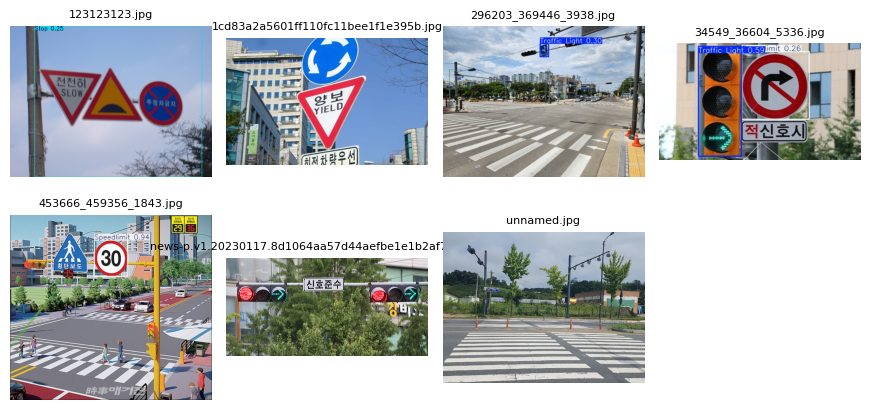

In [24]:
import matplotlib.pyplot as plt
import cv2
import math

img_dir = "/content/runs/detect/predict"
extensions = (".jpg", ".jpeg", ".png", ".bmp")

files = [f for f in os.listdir(img_dir) if f.lower().endswith(extensions)]
files = sorted(files)

# 🔹 행/열 개수 설정
cols = 4                     # 열(가로개수)
rows = math.ceil(len(files) / cols)

plt.figure(figsize=(cols*2.2, rows*2.2))   # 전체 크기

for i, f in enumerate(files):
    path = os.path.join(img_dir, f)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f, fontsize=8)

plt.tight_layout()
plt.show()
